<div style="background:#0A2372; color:white; padding:26px 30px; border-radius:8px">
<div style="color:#009E8A; font-weight:bold; letter-spacing:1px">OPERA CAPACITY DEVELOPMENT ACTIVITIES</div>
<div style="font-size:30px; font-weight:bold; margin-top:6px">From Ocean Literacy to Ocean Data</div>
<div style="font-size:18px; margin-top:4px">OPERA resources · Copernicus Marine Service · EDITO — a guided 2-hour hands-on session</div>
<div style="color:#FFCC03; margin-top:12px">Ocean Prediction Enhancement in Regions of Africa (OPERA) · OceanPrediction Decade Collaborative Centre</div>
</div>

### What you will be able to do after this session

1. **Find** the OPERA learning resources: Ocean Literacy materials, the MOOC pathway, the Advanced Interactive Activities and the upcoming SEA-FORWARD toolkit.
2. **Navigate** the Copernicus Marine Service website: the MyOcean viewers, the product catalogue and a product's documentation.
3. **Access** real Copernicus Marine data from Python for your own coastline: observations, model forecasts, currents and waves.
4. **Judge** a product: compare a model forecast with satellite observations and read the numbers critically.
5. **Discover** EDITO, the European Digital Twin of the Ocean, and query its data catalogue.

### Session plan (120 min)

| Time | Part | Format |
|---|---|---|
| 0:00 – 0:10 | **0 · Welcome and set-up** | 💻 run the set-up cell, log in |
| 0:10 – 0:25 | **1 · OPERA Capacity Development: what is available for you** | 📖 read + 💻 one figure |
| 0:25 – 0:50 | **2 · Guided tour of the Copernicus Marine Service website** | 🌐 browser, everyone follows |
| 0:50 – 1:40 | **3 · Hands-on: Copernicus Marine data in Python** | 💻 run, read, ✍️ exercises |
| 1:40 – 1:52 | **4 · EDITO, the European Digital Twin of the Ocean** | 🌐 + 💻 |
| 1:52 – 2:00 | **5 · Wrap-up, self-check and next steps** | 📖 |

**How to read this notebook:** 🌐 = do it in your web browser · 💻 = run the code cell (`Shift + Enter`) · ✍️ = your turn · ✋ = checkpoint, raise your hand if it did not work.

---
# Part 0 · Welcome and set-up <span style="color:#888; font-size:16px">(10 min)</span>

<div style="border-left:6px solid #009E8A; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#009E8A">🌐 Before we start — create your free Copernicus Marine account (2 min)</b><br>Go to <a href="https://data.marine.copernicus.eu/register">data.marine.copernicus.eu/register</a>, fill in the form and confirm the e-mail you receive. Keep your <b>username</b> and <b>password</b> at hand: you will need them in Part 3. Registration is free.</div>

<div style="border-left:6px solid #1A54EB; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#1A54EB">Where can I run this notebook?</b><br>Any Jupyter environment with internet access works: your own laptop (Jupyter Lab / VS Code), Google Colab, the <a href="https://marine.copernicus.eu/services/user-learning-services/jupyter-environment">Copernicus Marine Jupyter environment</a>, or the <a href="https://datalab.dive.edito.eu/">EDITO Datalab</a> (Part 4). The first cell installs anything that is missing.</div>

In [1]:
# 💻 Cell 0.1 — install missing packages (takes ~1 minute the first time, then instant)
import importlib.util, subprocess, sys

REQUIRED = {                      # python module -> pip package
    "copernicusmarine": "copernicusmarine",
    "xarray": "xarray", "pandas": "pandas", "numpy": "numpy",
    "matplotlib": "matplotlib", "cartopy": "cartopy",
    "requests": "requests", "zarr": "zarr", "fsspec": "fsspec", "aiohttp": "aiohttp",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("✅ All packages available")

✅ All packages available


In [2]:
# 💻 Cell 0.2 — imports and session settings
import warnings
from datetime import timedelta
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=RuntimeWarning)
import copernicusmarine as cm
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})

try:                                   # maps look better with cartopy (coastlines, borders)
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    USE_CARTOPY = True
except ImportError:
    USE_CARTOPY = False

# ---------------------------------------------------------------- session settings
# The default study region is the Gulf of Guinea domain used in the OPERA workshop.
# ✍️ You can change it later to your own coastline (Exercise 3.A).
REGION = dict(minimum_longitude=-10.0, maximum_longitude=15.0,
              minimum_latitude=-5.0,   maximum_latitude=10.0)
REGION_NAME = "Gulf of Guinea"

# Reference points (slightly offshore, so they fall in the ocean)
POINTS = {
    "Abidjan":     (5.15, -4.00),   # (latitude, longitude)
    "Accra":       (5.40, -0.20),
    "Cotonou":     (6.20,  2.43),
    "Lagos":       (6.30,  3.40),
    "Port-Gentil": (-0.65, 8.60),
}

TODAY       = pd.Timestamp.now(tz="UTC").tz_localize(None).normalize()
OBS_END     = TODAY - timedelta(days=3)     # near-real-time observations arrive with ~1-2 days delay
OBS_START   = OBS_END - timedelta(days=29)  # one month of observations
FC_START    = TODAY                          # forecasts: from today ...
FC_END      = TODAY + timedelta(days=7)      # ... to 7 days ahead

# Copernicus Marine datasets used in Part 3 (all GLOBAL products — see the note in Part 2)
DS = {
    "sst_obs":  "METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2",           # satellite SST, gap-free (L4), 0.05°
    "temp_fc":  "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m",  # model temperature, daily, 1/12°
    "cur_fc":   "cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m",     # model currents, daily, 1/12°
    "wave_fc":  "cmems_mod_glo_wav_anfc_0.083deg_PT3H-i",         # model waves, 3-hourly, 1/12°
    "chl_fc":   "cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m",       # model chlorophyll, daily, 1/4° (bonus)
}

print("Settings loaded — now run Cell 0.3")

Settings loaded — now run Cell 0.3


In [3]:
OBS_END

Timestamp('2026-10-01 00:00:00')

In [4]:
OBS_START

Timestamp('2026-09-02 00:00:00')

In [5]:
# 💻 Cell 0.3 — plotting helpers (just run it; no need to read it during the session)
def extent_of(region):
    return [region["minimum_longitude"], region["maximum_longitude"],
            region["minimum_latitude"], region["maximum_latitude"]]

def map_axes(nrows=1, ncols=1, figsize=(8, 5)):
    """Figure + axes, with a map projection when cartopy is available."""
    kw = {"subplot_kw": {"projection": ccrs.PlateCarree()}} if USE_CARTOPY else {}
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True, **kw)
    for ax in np.atleast_1d(axes).ravel():
        if USE_CARTOPY:
            ax.set_extent(extent_of(REGION), crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=2)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.4", zorder=3)
            gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6", alpha=0.6, linestyle=":")
            gl.top_labels = gl.right_labels = False
        else:
            ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
            ax.set_xlim(extent_of(REGION)[:2]); ax.set_ylim(extent_of(REGION)[2:])
            ax.set_facecolor("0.88")
    return fig, axes

def show_field(ax, da, cmap="RdYlBu_r", vmin=None, vmax=None, label=""):
    """Colour map of a 2-D (latitude, longitude) field with its colour bar."""
    kw = {"transform": ccrs.PlateCarree()} if USE_CARTOPY else {}
    m = ax.pcolormesh(da["longitude"], da["latitude"], da, cmap=cmap, vmin=vmin, vmax=vmax,
                      shading="auto", zorder=1, **kw)
    plt.colorbar(m, ax=ax, shrink=0.85, pad=0.02, label=label)
    return m

def mark_points(ax, points=None, color="k"):
    kw = {"transform": ccrs.PlateCarree()} if USE_CARTOPY else {}
    for i, (name, (lat, lon)) in enumerate((points or POINTS).items()):
        ax.plot(lon, lat, "o", ms=5, mec="white", mfc=color, zorder=5, **kw)
        dy = 0.35 if i % 2 == 0 else -0.75          # alternate labels above/below to avoid overlaps
        ax.text(lon + 0.2, lat + dy, name, fontsize=8, weight="bold", zorder=5, **kw)

def nearest_ocean(da2d, lat, lon):
    """(lat, lon) of the closest grid cell that has data (skips land cells next to the coast)."""
    lat2, lon2 = xr.broadcast(da2d["latitude"], da2d["longitude"])
    dist = (lat2 - lat) ** 2 + ((lon2 - lon) * np.cos(np.deg2rad(lat))) ** 2
    dist = dist.where(da2d.notnull())
    if not bool(dist.notnull().any()):
        raise ValueError("No ocean data near this point — enlarge the box or move the point offshore.")
    idx = np.unravel_index(int(np.nanargmin(dist.values)), dist.shape)
    return float(lat2.values[idx]), float(lon2.values[idx])

def surface(ds_or_da):
    """Keep the top model level when a depth axis exists."""
    return ds_or_da.isel(depth=0) if "depth" in ds_or_da.dims else ds_or_da

print(f"Region: {REGION_NAME} {extent_of(REGION)}")
print(f"Observations: {OBS_START:%d %b %Y} → {OBS_END:%d %b %Y}   |   Forecast: {FC_START:%d %b} → {FC_END:%d %b %Y}")
print(f"copernicusmarine toolbox v{cm.__version__} · maps with cartopy: {USE_CARTOPY}")

Region: Gulf of Guinea [-10.0, 15.0, -5.0, 10.0]
Observations: 02 Sep 2026 → 01 Oct 2026   |   Forecast: 04 Oct → 11 Oct 2026
copernicusmarine toolbox v2.5.0 · maps with cartopy: True


✋ **Checkpoint** — after Cell 0.3 you should see your region, the two time windows and the toolbox version. If not, call a trainer.

---
# Part 1 · OPERA Capacity Development: what is available for you <span style="color:#888; font-size:16px">(15 min)</span>

The **OPERA** ([Ocean Prediction Enhancement in Regions of Africa](https://www.unoceanprediction.org/en/ocean-prediction-enhancement-regions-africa-opera)) Capacity Development Activities are a 38-month programme (January 2026 – February 2029) funded by the [European Union](https://european-union.europa.eu/index_en). They are implemented by [Mercator Ocean International](https://www.mercator-ocean.eu/) within the framework of the [OceanPrediction Decade Collaborative Centre](https://www.unoceanprediction.org/), and led by the [ICMPA-UNESCO Chair (Université d'Abomey-Calavi, Benin)](https://www.icmpa.net/cipma/) and the [Gulf of Guinea Ocean Sciences Summer School (GGOSSS)](https://www.ggosss.org).

OPERA builds a **progressive pathway**: from ocean awareness, to learning, to practice, to building and running operational forecasting systems — with formal certification along the way.

| Work package | What it offers you | Status |
|---|---|---|
| **WP1 · Ocean Literacy** | Bilingual (EN/FR) videos, infographics, articles and factsheets for the public, educators and policymakers | Set 1 available ✅ |
| **WP2 · MOOC Pathway** | Four free online courses, from the fundamentals to operational services and digital twins | MOOC 1 delivered ✅ · MOOC 2 next |
| **WP3 · SEA-FORWARD** | Open learning toolkit to build, run and validate a regional ocean forecasting system on a standard computer | Upcoming 🔜 |
| **WP4 · Advanced Interactive Activities** | Live webinars and hands-on workshops with real Copernicus Marine and ERA5 data | Set 1 Oct–Nov 2026 |
| **WP5 · Certification** | MOOC certificates (ICMPA-UNESCO Chair, Université d'Abomey-Calavi); accreditation of the activities in discussion | In place ✅ |
| **WP6 · Dissemination** | Shares OPERA resources, results and opportunities across all work packages | Ongoing |

## 1.1 Ocean Literacy — Set 1 is out

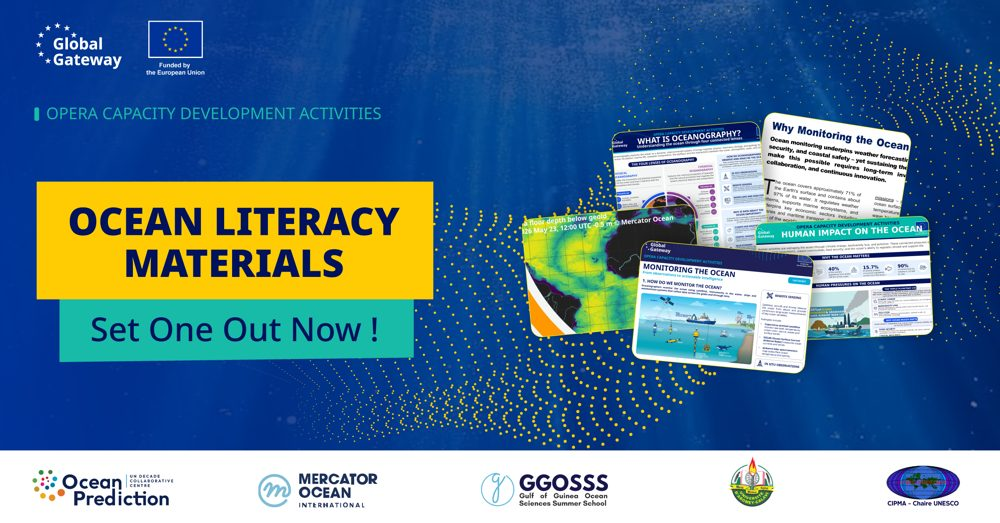

**Set 1 contains:** 1 video (*Introduction to oceanography*) · 2 infographics (*Branches of oceanography*, *Human impacts on the ocean*) · 1 article (*Why monitoring the ocean matters*, with regional use cases) · 1 factsheet (*How we monitor the ocean today*).

<div style="border-left:6px solid #009E8A; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#009E8A">🌐 Open the Ocean Literacy materials</b><br><a href="https://www.unoceanprediction.org/en/resource-center?field_resource_type%5B0%5D=ocean_literacy_materials">OceanPrediction DCC Resource Centre → Ocean Literacy materials</a>. Pick one infographic you would use with students or decision-makers in your country.</div>

## 1.2 The MOOC pathway

| MOOC | Title | What it covers | Period |
|---|---|---|---|
| **1** | [Fundamentals of Ocean Forecasting](https://www.futurelearn.com/courses/fundamentals-of-ocean-forecasting) | The end-to-end forecasting chain: ocean dynamics, observations, numerical models, data assimilation, products and applications | Open since 13 Jul 2026 |
| **2** | Building an Ocean Forecasting System | OceanPrediction DCC architecture, model selection and configuration, grids and forcing, data assimilation and validation, AI/ML | Nov 2026 – Aug 2027 |
| **3** | Operational Forecasting & Service | Assessing operational readiness; delivering reliable, actionable and sustainable services | Sep 2027 – Jun 2028 |
| **4** | Applications & Data Interoperability | Applying forecast products; interoperability and Digital Twin concepts | Jul 2027 – Feb 2029 |

**MOOC 1 at a glance:** 7 weeks · 4 hours per week · free · certificate of achievement · available now on FutureLearn.

**MOOC 1 in numbers:** 1,378 learners enrolled from 110 countries · + 906 active learners · + 11,855 comments · + 332 certified learners · 99 % of survey respondents said it met or exceeded their expectations.

The course is anchored in the [ETOOFS Guide](https://www.unoceanprediction.org/en/resources/etoofs-guide) — the international reference on implementing operational ocean forecasting systems.

👉 **[Join MOOC 1 on FutureLearn](https://www.futurelearn.com/courses/fundamentals-of-ocean-forecasting)**

💻 The cell below draws the whole OPERA pathway on one timeline, with today's date, so you can see where you can join.

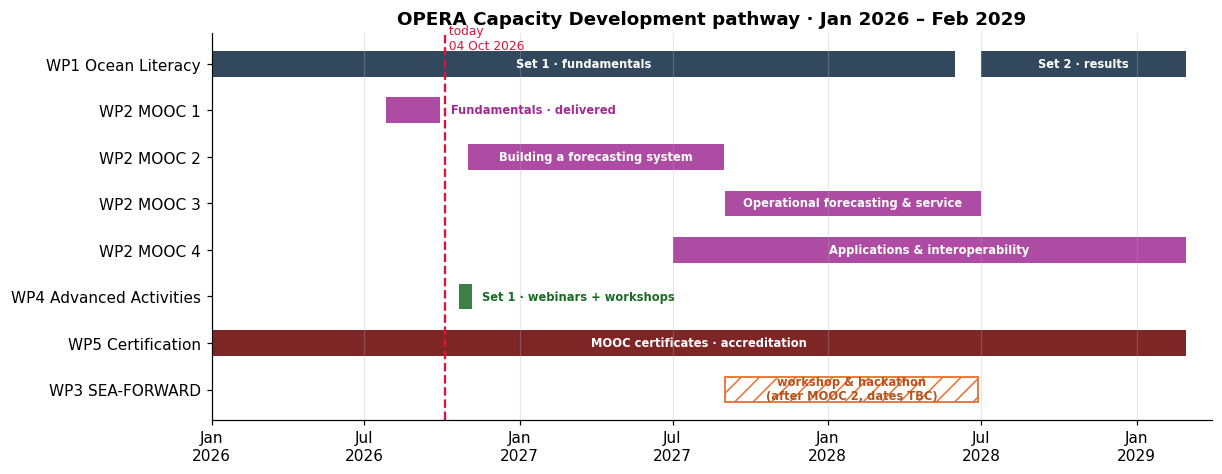

In [24]:
# 💻 Cell 1.1 — the OPERA capacity-development pathway on one timeline
D = pd.Timestamp
bars = [  # (row label, start, end, colour, text)
    ("WP1 Ocean Literacy",   D("2026-01-01"), D("2028-05-31"), "#0E2841", "Set 1 · fundamentals"),
    ("WP1 Ocean Literacy",   D("2028-07-01"), D("2029-02-28"), "#0E2841", "Set 2 · results"),
    ("WP2 MOOC 1",           D("2026-07-27"), D("2026-09-29"), "#A02B93", "Fundamentals · delivered"),
    ("WP2 MOOC 2",           D("2026-11-01"), D("2027-08-31"), "#A02B93", "Building a forecasting system"),
    ("WP2 MOOC 3",           D("2027-09-01"), D("2028-06-30"), "#A02B93", "Operational forecasting & service"),
    ("WP2 MOOC 4",           D("2027-07-01"), D("2029-02-28"), "#A02B93", "Applications & interoperability"),
    ("WP4 Advanced Activities", D("2026-10-21"), D("2026-11-05"), "#196B24", "Set 1 · webinars + workshops"),
    ("WP5 Certification",    D("2026-01-01"), D("2029-02-28"), "#680000", "MOOC certificates · accreditation"),
]
rows = list(dict.fromkeys(b[0] for b in bars))
fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
for label, start, end, colour, text in bars:
    y = rows.index(label)
    ax.barh(y, (end - start).days, left=start, height=0.55, color=colour, alpha=0.85)
    if (end - start).days > 150:          # label inside long bars, beside short ones
        ax.text(start + (end - start) / 2, y, text, ha="center", va="center", color="white", fontsize=7.5, weight="bold")
    else:
        ax.text(end + timedelta(days=12), y, text, ha="left", va="center", color=colour, fontsize=7.5, weight="bold")
# SEA-FORWARD: workshop and hackathon after MOOC 2 (dates to be confirmed)
y = len(rows); rows.append("WP3 SEA-FORWARD")
ax.barh(y, 300, left=D("2027-09-01"), height=0.55, color="none", edgecolor="#E97132", hatch="//", linewidth=1.2)
ax.text(D("2027-09-01") + timedelta(days=150), y, "workshop & hackathon\n(after MOOC 2, dates TBC)",
        ha="center", va="center", fontsize=7.5, color="#B5541B", weight="bold")
ax.axvline(TODAY, color="crimson", lw=1.5, ls="--")
ax.text(TODAY, -0.85, f" today\n {TODAY:%d %b %Y}", color="crimson", fontsize=8, va="top")
ax.set_yticks(range(len(rows)), rows); ax.invert_yaxis()
ax.set_xlim(D("2026-01-01"), D("2029-03-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7])); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(axis="x", alpha=0.3)
ax.set_title("OPERA Capacity Development pathway · Jan 2026 – Feb 2029")
plt.show()

## 1.3 Advanced Interactive Activities and SEA-FORWARD

**Advanced Interactive Activities (Set 1)** turn MOOC knowledge into practice with real data: live webinars on 21–23 October 2026
(Anglophone 08:00–10:00 GMT, Francophone 14:00–16:00 GMT), then hands-on workshops on 27–29 October (EN) and 3–5 November 2026 (FR).
The MOOC 1 certificate is the prerequisite. Details: [apply.ggosss.org/aia-set1](https://apply.ggosss.org/aia-set1/).

**SEA-FORWARD** (*Simple Educational Access for Forecast and Warning Developers*) is the upcoming hands-on step after MOOC 2:
an open learning toolkit to build and run a complete regional ocean forecasting system on your own computer — from raw input data to a
validated 5-day forecast, with the CROCO ocean model, in under 20 minutes on an 8-core, 16 GB machine. It follows the OceanPrediction DCC
[Ocean Forecasting Architecture Guide](https://www.unoceanprediction.org/en/resources/architecture).

| SEA-FORWARD architecture | SEA-FORWARD forecasting scheme |
|---|---|
| 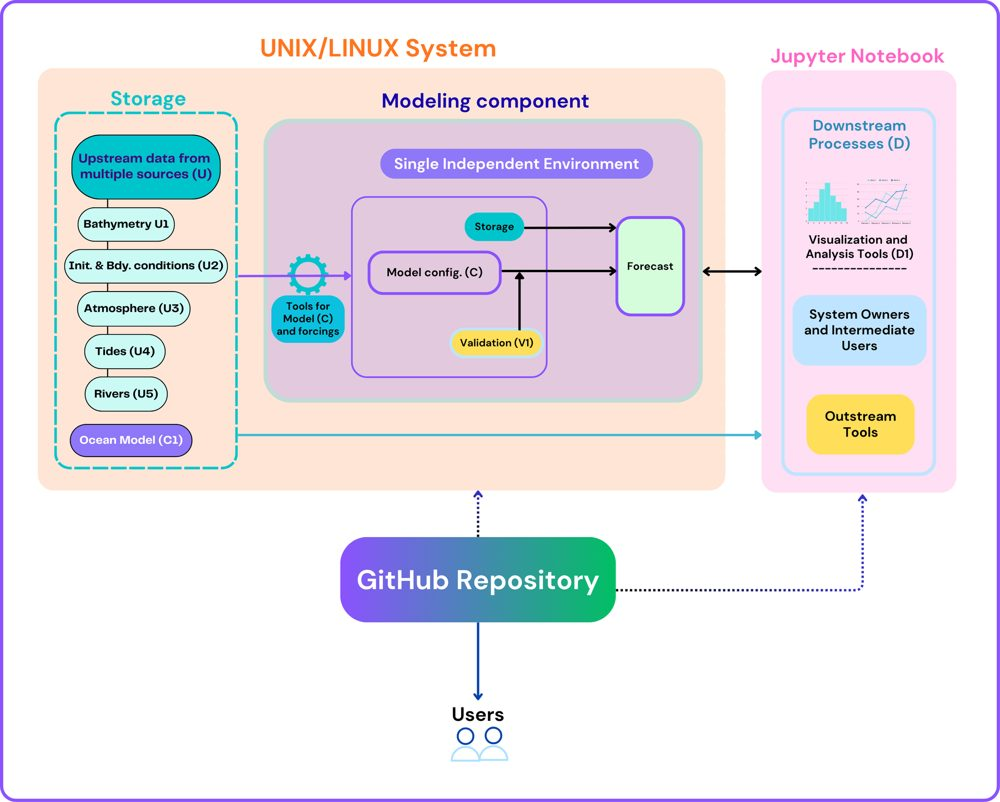 | 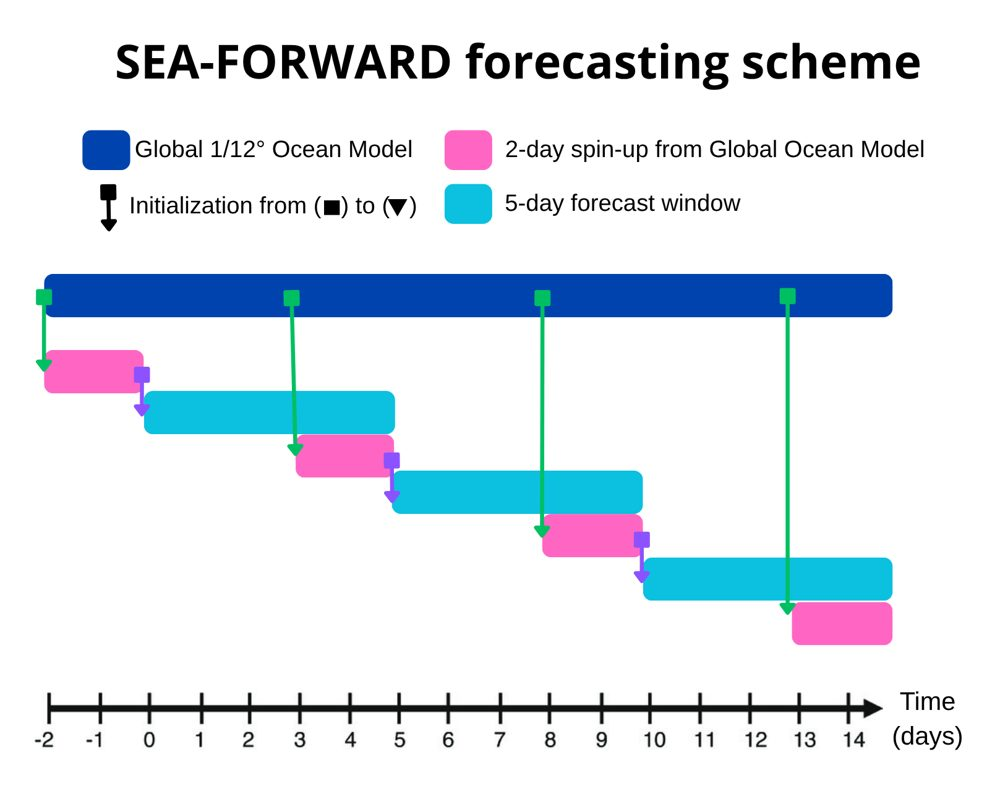 |

<div style="border-left:6px solid #1A54EB; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#1A54EB">🔗 Why this matters for today</b><br>SEA-FORWARD takes its initial and boundary conditions from the <b>global Copernicus Marine 1/12° model</b> — the same product you will open in Part 3. Understanding these products today is the first step towards running your own regional forecast tomorrow.</div>

---
# Part 2 · Guided tour of the Copernicus Marine Service website <span style="color:#888; font-size:16px">(25 min)</span>

The [Copernicus Marine Service](https://marine.copernicus.eu/) is the marine component of the EU Copernicus programme, implemented by
Mercator Ocean International. It provides **free and open** information on the **blue** (physics), **white** (sea ice) and **green**
(biogeochemistry) ocean: observations (satellite and in situ), analyses and forecasts, and reanalyses covering several decades.

<div style="border-left:6px solid #6B7280; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#6B7280">⚠️ Set expectations for Africa</b><br>Copernicus Marine has global products and regional products for European seas. There is <b>no dedicated West African regional product</b>: for African coasts we use the <b>global</b> products (1/12° ≈ 9 km for physics). This is exactly the gap that regional systems such as SEA-FORWARD address by downscaling.</div>

## 2.1 The viewer ladder — from discovery to expert queries 🌐

Everyone follows on screen. Tick each step when done.

| Step | Tool | What to do | Time |
|---|---|---|---|
| ☐ 1 | [**MyOcean Learn**](https://myoceanlearn.marine.copernicus.eu) | Spin the globe. Open one *Blue*, one *White* and one *Green* ocean variable and read its short explanation. | 4 min |
| ☐ 2 | [**MyOcean Light**](https://data.marine.copernicus.eu/viewer) | Zoom on **your coastline**. Display today's sea surface temperature; move the time slider back one month; change the depth. Export an image. | 7 min |
| ☐ 3 | [**MyOcean Pro**](https://data.marine.copernicus.eu/viewer/expert) | Add the layer *Global Ocean Physics Analysis and Forecast*. Click a point offshore of your city and plot its **time series**; export it as **CSV**. | 7 min |
| ☐ 4 | [**MyOcean Health**](https://myoceanhealth.marine.copernicus.eu/en) | Look at the ocean health indicators (sea surface temperature, marine heatwaves, sea level…). Is there a marine heatwave near you today? | 3 min |

## 2.2 Reading the product catalogue 🌐

Open the [**product catalogue**](https://data.marine.copernicus.eu/products) and search `GLOBAL_ANALYSISFORECAST_PHY_001_024`. On the product page, find:

- ☐ the **product ID** and the list of **dataset IDs** (tab *Data access*);
- ☐ the spatial resolution, the time coverage and the update frequency;
- ☐ the **Product User Manual (PUM)** and the **Quality Information Document (QUID)** — *read the documentation before using a product, not after a result looks strange*;
- ☐ the **DOI** to cite the product in a report or paper.

### Decoding a dataset ID

`cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m`

| Part | Meaning | Other values you will meet |
|---|---|---|
| `cmems` | Copernicus Marine | |
| `mod` | model output | `obs` observations |
| `glo` | global domain | `ibi`, `med`, `bal`, `nws`, `arc`, `blk` regional seas |
| `phy-thetao` | physics · potential temperature | `phy-cur` currents, `bgc-pft` phytoplankton, `wav` waves |
| `anfc` | **an**alysis and **f**ore**c**ast (near real time) | `my` multi-year (reanalysis) |
| `0.083deg` | 1/12° grid (≈ 9 km) | `0.25deg` |
| `P1D-m` | 1-day **m**eans | `PT1H-m` hourly means, `PT3H-i` 3-hourly **i**nstantaneous, `P1M-m` monthly |

<div style="border-left:6px solid #680000; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#680000">✋ Checkpoint (2 min)</b><br>In the catalogue, find the dataset ID of the <b>global wave forecast</b>. What is its time step? <details><summary>Answer</summary><code>cmems_mod_glo_wav_anfc_0.083deg_PT3H-i</code> — 3-hourly instantaneous fields.</details></div>

## 2.3 Help when you need it 🌐

[Help Centre](https://help.marine.copernicus.eu/en/) (articles and live chat) · [User learning services and training](https://marine.copernicus.eu/services/user-learning-services) ·
[Ocean State Report](https://marine.copernicus.eu/access-data/ocean-state-report) · [Ocean Monitoring Indicators](https://marine.copernicus.eu/access-data/ocean-monitoring-indicators) ·
[Copernicus Marine Toolbox documentation](https://toolbox-docs.marine.copernicus.eu/).

---
# Part 3 · Hands-on: Copernicus Marine data in Python <span style="color:#888; font-size:16px">(50 min)</span>

The viewers are perfect to explore; code is what you need to **repeat, automate and combine**. The
[Copernicus Marine Toolbox](https://toolbox-docs.marine.copernicus.eu/) (`copernicusmarine`) gives Python access to the whole catalogue.
Its key idea: `open_dataset()` opens the data **lazily** — only the region, period and variables you ask for are actually transferred.

| Step | You will… | Time |
|---|---|---|
| 3.1 | log in once | 3 min |
| 3.2 | search the catalogue from code | 5 min |
| 3.3 | map one month of satellite SST | 8 min |
| 3.4 | extract time series at coastal cities | 7 min |
| 3.5 | open the 7-day model forecast (temperature + currents) | 8 min |
| 3.6 | **judge the model**: compare it with the satellite | 8 min |
| 3.7 | forecast waves at Cotonou | 5 min |
| 3.8 | save your own subset as NetCDF | 3 min |
| ✍️ | exercises on your own coastline | rest |

## 3.1 Log in (once)

In [6]:
# 💻 Cell 3.1 — log in. Your credentials are stored in ~/.copernicusmarine, so you only do this once per computer.
from getpass import getpass

if cm.login(check_credentials_valid=True):
    print("✅ Already logged in")
else:
    username = input("Copernicus Marine username: ").strip()
    password = getpass("Copernicus Marine password: ")
    ok = cm.login(username=username, password=password, force_overwrite=True)
    print("✅ Logged in" if ok else "❌ Login failed — check your username/password or register at data.marine.copernicus.eu/register")

INFO - 2026-10-04T14:14:02Z - Checking if credentials are valid.
INFO - 2026-10-04T14:14:02Z - Valid credentials from configuration file.


✅ Already logged in


## 3.2 Search the catalogue from code
`describe()` returns the same catalogue you browsed in Part 2. Here we look for global products that contain a keyword.

In [7]:
# 💻 Cell 3.2 — which global products mention "sea surface temperature"?
KEYWORD = "sea surface temperature"     # ✍️ try: "wave", "chlorophyll", "sea level", "salinity"

catalogue = cm.describe(contains=[KEYWORD], disable_progress_bar=True)
rows = []
for p in catalogue.products:
    if "GLO" not in p.product_id:            # keep global products (relevant for Africa)
        continue
    for d in p.datasets:
        rows.append({"product_id": p.product_id, "product": p.title, "dataset_id": d.dataset_id})
found = pd.DataFrame(rows)
print(f"{found.product_id.nunique()} global products, {len(found)} datasets match '{KEYWORD}'")
found.head(15)

18 global products, 66 datasets match 'sea surface temperature'


,product_id,product,dataset_id
0,GLOBAL_ANALYSISFORECAST_PHY_001_024,Global Ocean Physics Analysis and Forecast,cmems_mod_glo_phy_anfc_0.083deg-sst-anomaly_P1D-m
1,GLOBAL_ANALYSISFORECAST_PHY_001_024,Global Ocean Physics Analysis and Forecast,cmems_mod_glo_phy_anfc_0.083deg-sst-anomaly_P1M-m
2,GLOBAL_MULTIYEAR_BGC_001_033,Global ocean low and mid trophic levels biomas...,cmems_mod_glo_bgc_my_0.083deg-lmtl-Fphy_P1D-i
3,GLOBAL_MULTIYEAR_BGC_001_033,Global ocean low and mid trophic levels biomas...,cmems_mod_glo_bgc_my_0.083deg-lmtl_P1D-i
4,GLOBAL_MULTIYEAR_PHY_001_030,Global Ocean Physics Reanalysis,cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m
5,GLOBAL_MULTIYEAR_PHY_001_030,Global Ocean Physics Reanalysis,cmems_mod_glo_phy_my_0.083deg_P1D-m
6,GLOBAL_MULTIYEAR_PHY_001_030,Global Ocean Physics Reanalysis,cmems_mod_glo_phy_my_0.083deg_P1M-m
7,GLOBAL_MULTIYEAR_PHY_001_030,Global Ocean Physics Reanalysis,cmems_mod_glo_phy_my_0.083deg_static
8,GLOBAL_OMI_CLIMVAR_enso_sst_area_averaged_anom...,Nino 3.4 Sea Surface Temperature time series f...,global_omi_climate-variability_nino34_sst_anom
9,GLOBAL_OMI_TEMPSAL_sst_area_averaged_anomalies,Global Ocean Sea Surface Temperature time seri...,global_omi_tempsal_sst_area_averaged_anomalies


In [8]:
# 💻 Cell 3.2b — check that the datasets used today are available in the catalogue
status = []
for key, dsid in DS.items():
    try:
        cat = cm.describe(dataset_id=dsid, disable_progress_bar=True)
        prod = cat.products[0]
        status.append({"use": key, "dataset_id": dsid, "product_id": prod.product_id, "available": "✅"})
    except Exception as err:
        status.append({"use": key, "dataset_id": dsid, "product_id": "—", "available": f"❌ {type(err).__name__}"})
pd.DataFrame(status)

,use,dataset_id,product_id,available
0,sst_obs,METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2,SST_GLO_SST_L4_NRT_OBSERVATIONS_010_001,✅
1,temp_fc,cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m,GLOBAL_ANALYSISFORECAST_PHY_001_024,✅
2,cur_fc,cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m,GLOBAL_ANALYSISFORECAST_PHY_001_024,✅
3,wave_fc,cmems_mod_glo_wav_anfc_0.083deg_PT3H-i,GLOBAL_ANALYSISFORECAST_WAV_001_027,✅
4,chl_fc,cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m,GLOBAL_ANALYSISFORECAST_BGC_001_028,✅


<div style="border-left:6px solid #6B7280; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#6B7280">If a dataset shows ❌</b><br>Products are sometimes renamed when a new version is released. Search the new ID in the catalogue (Part 2.2) or with Cell 3.2, update it in the <code>DS</code> dictionary of Cell 0.2, and re-run.</div>

## 3.3 One month of satellite sea surface temperature

We use **OSTIA**, a gap-free (Level 4) daily SST analysis built from several satellites and in situ data, at 0.05° (≈ 5 km).

In [9]:
# 💻 Cell 3.3 — open one month of satellite SST over the region (lazy: nothing is downloaded yet)
sst_obs_ds = cm.open_dataset(
    dataset_id=DS["sst_obs"],
    variables=["analysed_sst"],
    start_datetime=OBS_START, end_datetime=OBS_END,
    **REGION,
)
sst_obs = (sst_obs_ds["analysed_sst"] - 273.15).load()   # Kelvin → °C, then download the subset
sst_obs.attrs["units"] = "°C"
print(f"{sst_obs.sizes['time']} days × {sst_obs.sizes['latitude']} × {sst_obs.sizes['longitude']} grid points  "
      f"({sst_obs.nbytes / 1e6:.0f} MB in memory)")
sst_obs_ds

INFO - 2026-10-04T14:16:05Z - Selected dataset version: "default"
INFO - 2026-10-04T14:16:05Z - Selected dataset part: "default"


29 days × 300 × 500 grid points  (35 MB in memory)


<xarray.Dataset> Size: 35MB
Dimensions:       (time: 29, latitude: 300, longitude: 500)
Coordinates:
  * time          (time) datetime64[ns] 232B 2026-09-02 ... 2026-09-30
  * latitude      (latitude) float32 1kB -4.975 -4.925 -4.875 ... 9.925 9.975
  * longitude     (longitude) float32 2kB -9.975 -9.925 -9.875 ... 14.93 14.98
Data variables:
    analysed_sst  (time, latitude, longitude) float64 35MB 297.7 297.7 ... nan
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              enquiries@metoffice.gov.uk
    ...                         ...
    time_coverage_end:          20240119T000000Z
    time_coverage_start:        20240118T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       536d4865-f5a8-45b2-806f-1f1db491069a
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.5.0

In [10]:
OBS_END

Timestamp('2026-10-01 00:00:00')

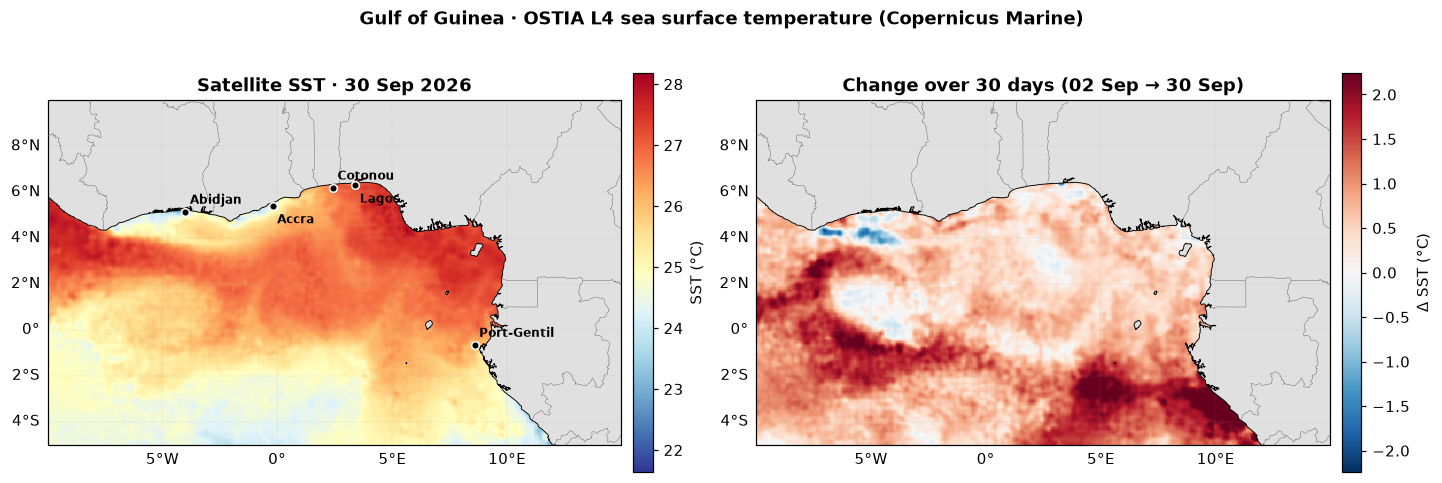

In [11]:
# 💻 Cell 3.3b — latest map and change over the month
last, first = sst_obs.isel(time=-1), sst_obs.isel(time=0)
change = last - first
fig, axes = map_axes(1, 2, figsize=(13, 4.6))
show_field(axes[0], last, cmap="RdYlBu_r", label="SST (°C)")
mark_points(axes[0])
axes[0].set_title(f"Satellite SST · {pd.Timestamp(last.time.values):%d %b %Y}")
lim = float(np.nanpercentile(np.abs(change), 98))
show_field(axes[1], change, cmap="RdBu_r", vmin=-lim, vmax=lim, label="Δ SST (°C)")
axes[1].set_title(f"Change over 30 days ({pd.Timestamp(first.time.values):%d %b} → {pd.Timestamp(last.time.values):%d %b})")
fig.suptitle(f"{REGION_NAME} · OSTIA L4 sea surface temperature (Copernicus Marine)", weight="bold")
plt.show()

<div style="border-left:6px solid #E97132; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#E97132">✍️ Read the map (2 min)</b><br>Where is the coolest water along the coast? Has the region warmed or cooled over the month? In the northern Gulf of Guinea, a <b>seasonal coastal upwelling</b> brings cold water along Côte d&#39;Ivoire and Ghana, mainly from July to September. Can you still see its trace?</div>

## 3.4 Time series at coastal cities

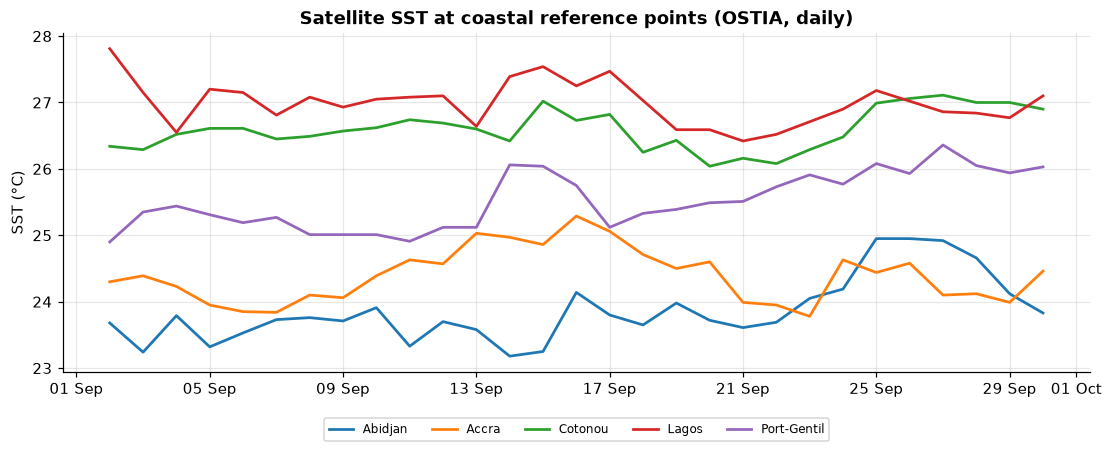

,grid lat,grid lon,mean (°C),min (°C),max (°C),change (°C)
point,,,,,,
Abidjan,5.12,-4.03,23.86,23.18,24.95,0.15
Accra,5.38,-0.22,24.39,23.78,25.29,0.16
Cotonou,6.18,2.42,26.60,26.04,27.11,0.56
Lagos,6.32,3.42,26.99,26.42,27.81,-0.71
Port-Gentil,-0.62,8.62,25.52,24.90,26.36,1.13


In [13]:
# 💻 Cell 3.4 — SST time series at the reference points (nearest ocean grid cell)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
summary = []
for name, (lat, lon) in POINTS.items():
    plat, plon = nearest_ocean(sst_obs.isel(time=-1), lat, lon)
    ts = sst_obs.sel(latitude=plat, longitude=plon)
    ax.plot(ts["time"], ts, lw=1.8, label=name)
    summary.append({"point": name, "grid lat": round(plat, 2), "grid lon": round(plon, 2),
                    "mean (°C)": round(float(ts.mean()), 2), "min (°C)": round(float(ts.min()), 2),
                    "max (°C)": round(float(ts.max()), 2), "change (°C)": round(float(ts[-1] - ts[0]), 2)})
ax.set_ylabel("SST (°C)"); ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b")); ax.grid(alpha=0.3)
ax.set_title("Satellite SST at coastal reference points (OSTIA, daily)")
plt.show()
pd.DataFrame(summary).set_index("point")

## 3.5 The 7-day model forecast: temperature and currents
The global analysis-and-forecast system runs every day and provides a 10-day forecast. We open the surface level.

In [14]:
# 💻 Cell 3.5 — open the forecast (surface temperature + surface currents)
top = dict(minimum_depth=0, maximum_depth=1)        # top model level (~0.5 m)
temp_fc = cm.open_dataset(dataset_id=DS["temp_fc"], variables=["thetao"],
                          start_datetime=FC_START, end_datetime=FC_END, **REGION, **top)
cur_fc = cm.open_dataset(dataset_id=DS["cur_fc"], variables=["uo", "vo"],
                         start_datetime=FC_START, end_datetime=FC_END, **REGION, **top)
sst_fc = surface(temp_fc["thetao"]).load()
u, v = surface(cur_fc["uo"]).load(), surface(cur_fc["vo"]).load()
speed = np.hypot(u, v)
print("Forecast days:", ", ".join(f"{pd.Timestamp(t):%d %b}" for t in sst_fc.time.values))

INFO - 2026-10-04T14:26:29Z - Selected dataset version: "202406"
INFO - 2026-10-04T14:26:29Z - Selected dataset part: "default"
WARNING - 2026-10-04T14:26:29Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-10-04T14:26:36Z - Selected dataset version: "202406"
INFO - 2026-10-04T14:26:36Z - Selected dataset part: "default"
WARNING - 2026-10-04T14:26:36Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


Forecast days: 04 Oct, 05 Oct, 06 Oct, 07 Oct, 08 Oct, 09 Oct, 10 Oct


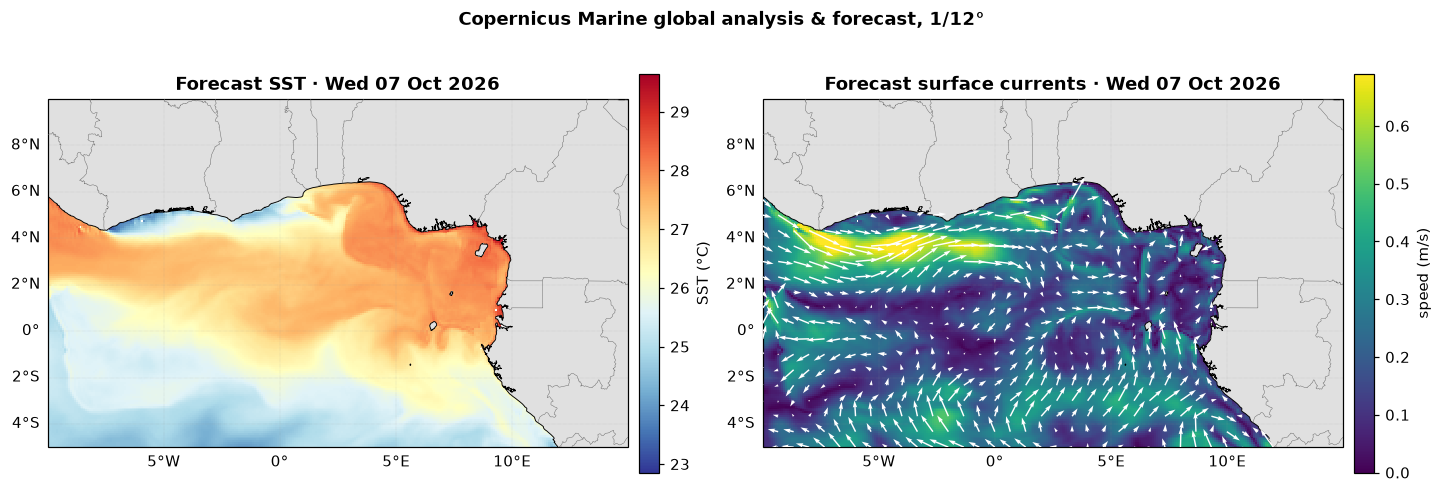

In [15]:
# 💻 Cell 3.5b — map of a forecast day with surface currents
LEAD = 3                                   # ✍️ forecast day to show (0 = today)
t = sst_fc.time.values[min(LEAD, sst_fc.sizes["time"] - 1)]
fig, axes = map_axes(1, 2, figsize=(13, 4.6))
show_field(axes[0], sst_fc.sel(time=t), cmap="RdYlBu_r", label="SST (°C)")
axes[0].set_title(f"Forecast SST · {pd.Timestamp(t):%a %d %b %Y}")
show_field(axes[1], speed.sel(time=t), cmap="viridis", vmin=0, vmax=float(speed.quantile(0.99)), label="speed (m/s)")
step = max(1, sst_fc.sizes["longitude"] // 35)          # thin the arrows for readability
uu, vv = u.sel(time=t)[::step, ::step], v.sel(time=t)[::step, ::step]
kw = {"transform": ccrs.PlateCarree()} if USE_CARTOPY else {}
axes[1].quiver(uu.longitude, uu.latitude, uu, vv, color="white", scale=12, width=0.0025, zorder=4, **kw)
axes[1].set_title(f"Forecast surface currents · {pd.Timestamp(t):%a %d %b %Y}")
fig.suptitle("Copernicus Marine global analysis & forecast, 1/12°", weight="bold")
plt.show()

<div style="border-left:6px solid #E97132; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#E97132">✍️ Read the forecast (2 min)</b><br>Can you locate the eastward <b>Guinea Current</b> along the northern coast? Change <code>LEAD</code> to 0 and 6: how much does the pattern change in a week?</div>

## 3.6 How good is this product? Model versus satellite

A forecast is only useful if you know its limits. We compare the model **analysis** with the satellite observations for the same day.

INFO - 2026-10-04T14:39:31Z - Selected dataset version: "202406"
INFO - 2026-10-04T14:39:31Z - Selected dataset part: "default"
WARNING - 2026-10-04T14:39:31Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


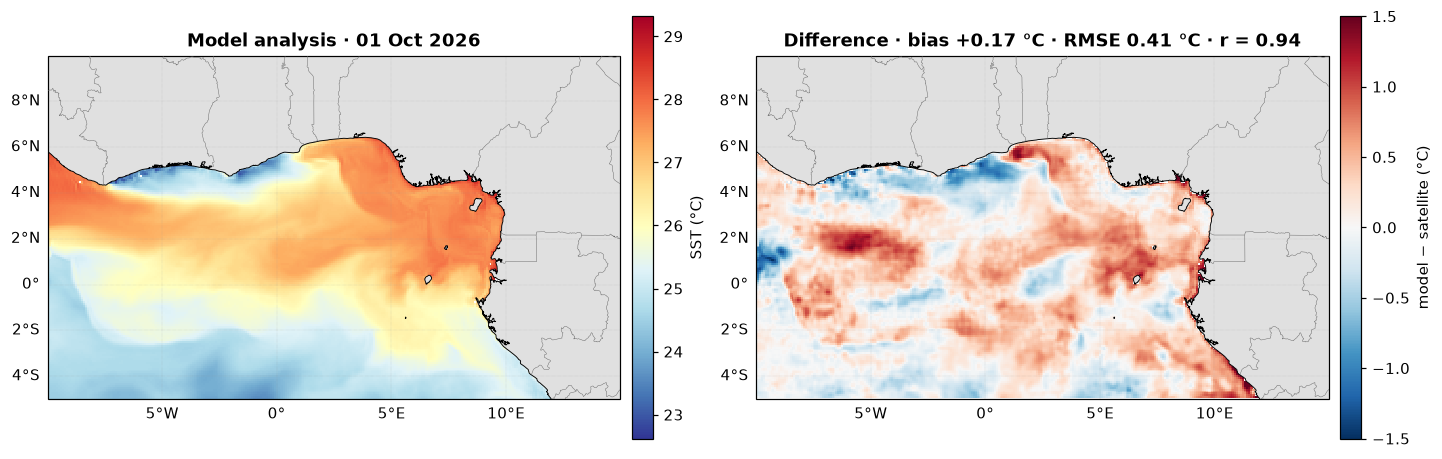

Bias +0.17 °C  |  RMSE 0.41 °C  |  spatial correlation 0.94  |  28832 grid points


In [16]:
# 💻 Cell 3.6 — model vs satellite on the most recent common day
DAY = OBS_END
temp_an = cm.open_dataset(dataset_id=DS["temp_fc"], variables=["thetao"],
                          start_datetime=DAY, end_datetime=DAY, **REGION, **top)
model = surface(temp_an["thetao"]).isel(time=0).load()
obs = sst_obs.sel(time=DAY, method="nearest")
obs_on_model = obs.interp_like(model)                  # put the satellite field on the model grid
diff = (model - obs_on_model).where(obs_on_model.notnull() & model.notnull())

valid = diff.notnull()
bias = float(diff.mean()); rmse = float(np.sqrt((diff ** 2).mean()))
corr = float(xr.corr(model.where(valid), obs_on_model.where(valid)))

fig, axes = map_axes(1, 2, figsize=(13, 4.6))
show_field(axes[0], model, cmap="RdYlBu_r", label="SST (°C)")
axes[0].set_title(f"Model analysis · {pd.Timestamp(DAY):%d %b %Y}")
show_field(axes[1], diff, cmap="RdBu_r", vmin=-1.5, vmax=1.5, label="model − satellite (°C)")
axes[1].set_title(f"Difference · bias {bias:+.2f} °C · RMSE {rmse:.2f} °C · r = {corr:.2f}")
plt.show()

print(f"Bias {bias:+.2f} °C  |  RMSE {rmse:.2f} °C  |  spatial correlation {corr:.2f}  |  {int(valid.sum())} grid points")

<div style="border-left:6px solid #1A54EB; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#1A54EB">How to read these numbers</b><br><b>Bias</b> = average difference (is the model systematically too warm or too cold?). <b>RMSE</b> = typical size of the error. <b>Correlation</b> = does the model put warm and cold water in the right places? Two caveats: the model gives the temperature of its top layer (~0.5 m) while OSTIA estimates the <i>foundation</i> SST, so they are not exactly the same quantity; and accuracy usually <b>degrades near the coast</b>. The product QUID (Part 2.2) gives the official validation statistics. <i>Knowing a product&#39;s limits is part of using it properly.</i></div>

## 3.7 Wave forecast at Cotonou

INFO - 2026-10-04T14:39:43Z - Selected dataset version: "202411"
INFO - 2026-10-04T14:39:43Z - Selected dataset part: "default"


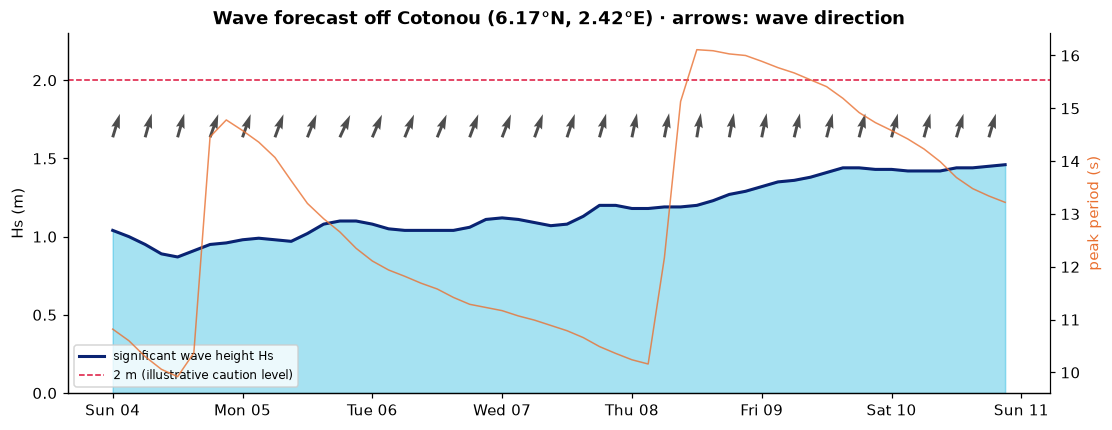

Max Hs 1.46 m on Sat 10 Oct 21:00 UTC


In [17]:
# 💻 Cell 3.7 — significant wave height forecast at a coastal point
CITY = "Cotonou"                            # ✍️ try another point from POINTS
lat, lon = POINTS[CITY]
box_ = dict(minimum_latitude=lat - 1.0, maximum_latitude=lat + 1.0,      # small box around the point
            minimum_longitude=lon - 1.0, maximum_longitude=lon + 1.0)
waves = cm.open_dataset(dataset_id=DS["wave_fc"], variables=["VHM0", "VTPK", "VMDR"],
                        start_datetime=FC_START, end_datetime=FC_END, **box_).load()
plat, plon = nearest_ocean(waves["VHM0"].isel(time=0), lat, lon)
w = waves.sel(latitude=plat, longitude=plon)

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
ax.fill_between(w.time, 0, w.VHM0, color="#00ADDC", alpha=0.35)
ax.plot(w.time, w.VHM0, color="#0A2372", lw=2, label="significant wave height Hs")
ax.axhline(2.0, color="crimson", ls="--", lw=1, label="2 m (illustrative caution level)")
step = max(1, w.sizes["time"] // 20)                       # arrows = direction the waves come from
ax.quiver(w.time[::step], np.full(w.time[::step].shape, float(w.VHM0.max()) * 1.12),
          -np.sin(np.deg2rad(w.VMDR[::step])), -np.cos(np.deg2rad(w.VMDR[::step])),
          scale=40, width=0.003, color="0.3")
ax.set_ylim(0, max(2.3, float(w.VHM0.max()) * 1.25)); ax.set_ylabel("Hs (m)")
# ax.set_ylim(0, float(w.VHM0.max()) * 1.25); ax.set_ylabel("Hs (m)")
ax2 = ax.twinx(); ax2.plot(w.time, w.VTPK, color="#E97132", lw=1, alpha=0.8); ax2.set_ylabel("peak period (s)", color="#E97132")
ax2.spines["right"].set_visible(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d")); ax.legend(loc="lower left", fontsize=8)
ax.set_title(f"Wave forecast off {CITY} ({plat:.2f}°N, {plon:.2f}°E) · arrows: wave direction")
plt.show()
print(f"Max Hs {float(w.VHM0.max()):.2f} m on {pd.Timestamp(w.VHM0.idxmax('time').values):%a %d %b %H:%M} UTC")

## 3.8 Save your own subset as a NetCDF file
Always check the size with a **dry run** before downloading.

In [38]:
# 💻 Cell 3.8 — dry run first, then download
request = dict(dataset_id=DS["temp_fc"], variables=["thetao"],
               start_datetime=FC_START, end_datetime=FC_END, **REGION, **top,
               output_filename=f"opera_{REGION_NAME.replace(' ', '_')}_sst_forecast.nc")
dry = cm.subset(**request, dry_run=True)
print(f"Would download ≈ {dry.file_size:.1f} MB  →  {dry.filename}")

DOWNLOAD = False                        # ✍️ set to True to actually save the file
if DOWNLOAD:
    res = cm.subset(**request, overwrite=True)
    print("✅ Saved:", res.file_path)

INFO - 2026-10-04T02:00:54Z - Selected dataset version: "202406"
INFO - 2026-10-04T02:00:54Z - Selected dataset part: "default"
WARNING - 2026-10-04T02:00:54Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-10-04T02:00:58Z - Total size of the download: 1.47 MB.


Would download ≈ 1.5 MB  →  opera_Gulf_of_Guinea_sst_forecast.nc


## ✍️ Exercises — make it yours

<div style="border-left:6px solid #E97132; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#E97132">Exercise 3.A · Your own coastline</b><br>In Cell 0.2, change <code>REGION</code>, <code>REGION_NAME</code> and <code>POINTS</code> to your country, then re-run Cells 0.2 → 3.7. <details><summary>Example: Senegal / Mauritania upwelling</summary><code>REGION = dict(minimum_longitude=-20, maximum_longitude=-14, minimum_latitude=12, maximum_latitude=22)</code><br><code>POINTS = {"Dakar": (14.7, -17.6), "Nouakchott": (18.1, -16.2)}</code></details></div>

<div style="border-left:6px solid #E97132; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#E97132">Exercise 3.B · Another variable</b><br>Use Cell 3.2 with the keyword <code>"sea level"</code>, pick a dataset and map its variable for the last day, re-using the code of Cell 3.3b. <details><summary>Hint</summary>The daily dataset <code>cmems_mod_glo_phy_anfc_0.083deg_P1D-m</code> contains the sea surface height <code>zos</code>.</details></div>

<div style="border-left:6px solid #E97132; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#E97132">Exercise 3.C · Bonus — ocean colour from the model (chlorophyll)</b><br>Run the next cell. Where is the ocean most productive, and why could that be near the coast and the river mouths?</div>

INFO - 2026-10-04T14:39:54Z - Selected dataset version: "202311"
INFO - 2026-10-04T14:39:54Z - Selected dataset part: "default"
WARNING - 2026-10-04T14:39:54Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]


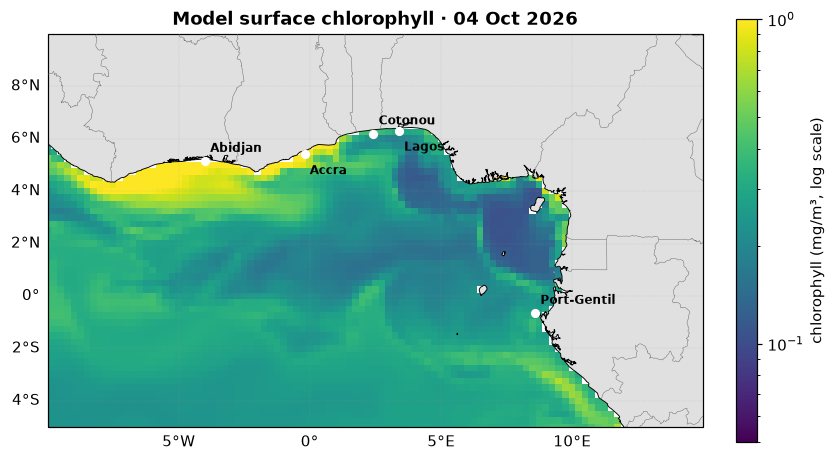

In [18]:
# 💻 Cell 3.C — bonus: forecast surface chlorophyll (biogeochemistry, 1/4°)
from matplotlib.colors import LogNorm
chl = surface(cm.open_dataset(dataset_id=DS["chl_fc"], variables=["chl"],
                              start_datetime=FC_START, end_datetime=FC_START, **REGION, **top)["chl"]).isel(time=0).load()
fig, ax = map_axes(figsize=(7.5, 4.6))
kw = {"transform": ccrs.PlateCarree()} if USE_CARTOPY else {}
m = ax.pcolormesh(chl.longitude, chl.latitude, chl, cmap="viridis", norm=LogNorm(0.05, 1), shading="auto", **kw)
plt.colorbar(m, ax=ax, shrink=0.85, label="chlorophyll (mg/m³, log scale)")
mark_points(ax, color="white")
ax.set_title(f"Model surface chlorophyll · {pd.Timestamp(chl.time.values):%d %b %Y}")
plt.show()

INFO - 2026-10-04T14:40:24Z - Selected dataset version: "202311"
INFO - 2026-10-04T14:40:24Z - Selected dataset part: "latest"
WARNING - 2026-10-04T14:40:24Z - Some of your subset selection [2026-09-01 23:00:00+00:00, 2026-09-30 23:00:00+00:00] for the time dimension exceed the dataset coordinates [2026-09-04 00:00:00+00:00, 2026-10-04 12:38:00+00:00]
100%|███████████████████████████████████████████████████████████| [00:02<00:00]

1,381 good-quality near-surface temperature measurements from 86 platforms


,measurements,platforms
platform_type,,
PF,1067,41
TS,258,44
MO,56,1


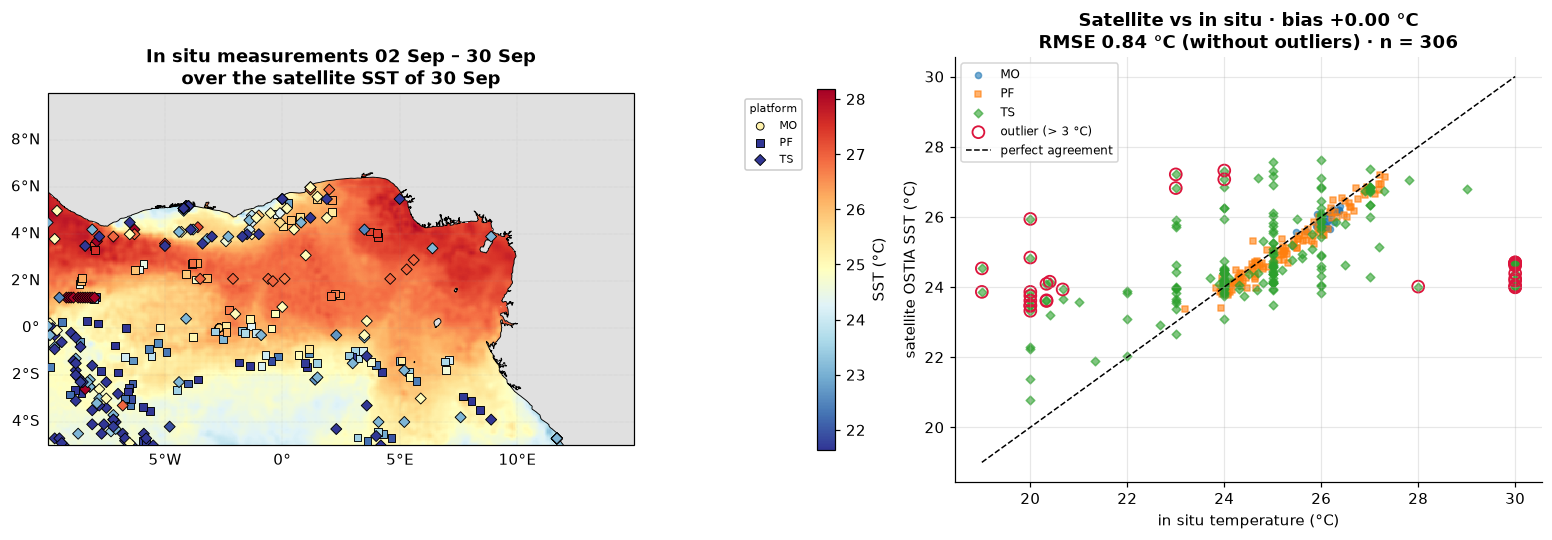

,n,bias (°C),RMSE (°C),outliers > 3 °C,bias w/o outliers,RMSE w/o outliers
platform type,,,,,,
MO,28.0,-0.20,0.25,0.0,-0.20,0.25
PF,112.0,-0.18,0.29,0.0,-0.18,0.29
TS,198.0,0.15,2.13,32.0,0.16,1.11
ALL,338.0,0.01,1.64,32.0,0.00,0.84


In [19]:
# 💻 Cell 3.9 — in situ observations (Argo floats, ships, moorings…) and an independent check of the satellite
INSITU_DS = "cmems_obs-ins_glo_phybgcwav_mynrt_na_irr"     # Global Ocean In-Situ Near-Real-Time Observations

insitu = cm.read_dataframe(
    dataset_id=INSITU_DS, dataset_part="latest",           # "latest" = last ~30 days; "history" = since 2020
    variables=["TEMP"],                                     # sea temperature (°C)
    start_datetime=OBS_START, end_datetime=OBS_END,
    minimum_depth=0, maximum_depth=5,                       # near-surface measurements only
    **REGION,
)
insitu = insitu.reset_index() if "time" not in insitu.columns else insitu
if "value_qc" in insitu.columns:                            # keep only data flagged "good" (QC = 1)
    insitu = insitu[insitu["value_qc"] == 1]
insitu = insitu.dropna(subset=["value"]).copy()
print(f"{len(insitu):,} good-quality near-surface temperature measurements from "
      f"{insitu['platform_id'].nunique() if 'platform_id' in insitu else '?'} platforms")

if insitu.empty:
    print("No in situ data in this region/period — try dataset_part='history' and an older period.")
else:
    ptype = "platform_type" if "platform_type" in insitu.columns else "platform_id"
    display(insitu.groupby(ptype).agg(measurements=("value", "size"),
                                      platforms=("platform_id", "nunique")).sort_values("measurements", ascending=False))

    # ---- one value per platform, per day, per satellite grid cell (ships move ~400 km a day)
    insitu["day"] = pd.to_datetime(insitu["time"], utc=True).dt.tz_localize(None).dt.floor("D")   # UTC, no time-zone label
    res = float(abs(sst_obs.latitude[1] - sst_obs.latitude[0]))                                       # 0.05° for OSTIA
    insitu["cell_lat"] = (insitu["latitude"] / res).round() * res
    insitu["cell_lon"] = (insitu["longitude"] / res).round() * res
    daily = (insitu.groupby(["platform_id", ptype, "day", "cell_lat", "cell_lon"], as_index=False)
                   .agg(latitude=("latitude", "mean"), longitude=("longitude", "mean"), value=("value", "mean")))

    # ---- satellite (OSTIA, Cell 3.3) at the same place and day
    t0, t1 = pd.Timestamp(sst_obs.time.values[0]), pd.Timestamp(sst_obs.time.values[-1])
    daily = daily[(daily["day"] >= t0) & (daily["day"] <= t1)].copy()
    sat = sst_obs.sel(time=xr.DataArray(daily["day"].values, dims="obs"),
                      latitude=xr.DataArray(daily["latitude"].values, dims="obs"),
                      longitude=xr.DataArray(daily["longitude"].values, dims="obs"), method="nearest")
    daily["satellite"] = sat.values
    daily = daily.dropna(subset=["satellite"])
    daily["diff"] = daily["satellite"] - daily["value"]
    ok = daily["diff"].abs() <= 3                              # gross outliers (> 3 °C) shown in red

    # ---- figure: map of measurements + satellite vs in situ
    fig = plt.figure(figsize=(14, 4.8), constrained_layout=True)
    kw_map = {"projection": ccrs.PlateCarree()} if USE_CARTOPY else {}
    ax1 = fig.add_subplot(1, 2, 1, **kw_map)
    if USE_CARTOPY:
        ax1.set_extent(extent_of(REGION), crs=ccrs.PlateCarree())
        ax1.add_feature(cfeature.LAND, facecolor="0.88", zorder=2); ax1.add_feature(cfeature.COASTLINE, lw=0.6, zorder=3)
        gl = ax1.gridlines(draw_labels=True, lw=0.3, color="0.6", alpha=0.6, ls=":"); gl.top_labels = gl.right_labels = False
    kw = {"transform": ccrs.PlateCarree()} if USE_CARTOPY else {}
    show_field(ax1, sst_obs.isel(time=-1), cmap="RdYlBu_r", label="SST (°C)")
    vmin, vmax = float(sst_obs.isel(time=-1).quantile(0.02)), float(sst_obs.isel(time=-1).quantile(0.98))
    for i, (pt, g) in enumerate(daily.groupby(ptype)):
        ax1.scatter(g["longitude"], g["latitude"], c=g["value"], cmap="RdYlBu_r", vmin=vmin, vmax=vmax,
                    marker="osD^vP*"[i % 7], s=26, edgecolors="k", linewidths=0.6, zorder=6, label=str(pt), **kw)
    ax1.legend(fontsize=7, title="platform", title_fontsize=7, loc="upper left", bbox_to_anchor=(1.18, 1), framealpha=1)
    ax1.set_title(f"In situ measurements {t0:%d %b} – {t1:%d %b}\nover the satellite SST of {t1:%d %b}")

    ax2 = fig.add_subplot(1, 2, 2)
    for i, (pt, g) in enumerate(daily.groupby(ptype)):
        ax2.scatter(g["value"], g["satellite"], s=16, alpha=0.6, marker="osD^vP*"[i % 7], label=str(pt))
    ax2.scatter(daily.loc[~ok, "value"], daily.loc[~ok, "satellite"], s=60, facecolors="none", edgecolors="crimson",
                lw=1.2, label="outlier (> 3 °C)")
    lo, hi = float(daily[["value", "satellite"]].min().min()), float(daily[["value", "satellite"]].max().max())
    ax2.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect agreement")
    ax2.set_xlabel("in situ temperature (°C)"); ax2.set_ylabel("satellite OSTIA SST (°C)"); ax2.legend(fontsize=8)
    ax2.set_title(f"Satellite vs in situ · bias {daily.loc[ok, 'diff'].mean():+.2f} °C\n"
                  f"RMSE {np.sqrt((daily.loc[ok, 'diff']**2).mean()):.2f} °C (without outliers) · n = {int(ok.sum())}")
    ax2.grid(alpha=0.3)
    plt.show()

    # ---- scores per platform type, with and without gross outliers
    def scores(g):
        good = g["diff"].abs() <= 3
        return pd.Series({"n": len(g), "bias (°C)": g["diff"].mean(), "RMSE (°C)": np.sqrt((g["diff"] ** 2).mean()),
                          "outliers > 3 °C": int((~good).sum()),
                          "bias w/o outliers": g.loc[good, "diff"].mean(),
                          "RMSE w/o outliers": np.sqrt((g.loc[good, "diff"] ** 2).mean())})
    table = pd.DataFrame({pt: scores(g) for pt, g in daily.groupby(ptype)}).T
    table.loc["ALL"] = scores(daily)
    table.index.name = "platform type"
    display(table.round(2))

### 🛟 Who measured the ocean? Reading the platform codes

In situ ("in place") observations are made **by instruments in the water**. They are the **reference**: satellites only see the surface, and models compute — in situ data are what we use to check both, and what data assimilation also feeds into forecast models.

| Code | Platform | How it measures | What you get |
|---|---|---|---|
| **`PF`** | **Profiling float (Argo)** | Drifts with the currents; every ~10 days dives to ~2,000 m and rises to the surface measuring temperature and salinity, then sends its data by satellite | Vertical profiles, scattered over the ocean (~4,000 floats worldwide) |
| **`TS`** | **Thermosalinograph** | Sensor on a ship's seawater intake (~5 m depth), measuring continuously while the ship sails | Lines of surface data along ship routes |
| **`MO`** | **Mooring** | Buoy anchored to the seafloor, measuring at a fixed position all the time — in the Gulf of Guinea, the **PIRATA** array (since 1997) | Long, continuous time series at one point |
| `DB` | Drifting buoy | Surface drifter following the currents | Surface temperature and currents along its path |
| `GL` | Glider | Autonomous underwater vehicle steered along a path | Dense sections along a line |
| `CT` | CTD profile | Instrument lowered from a research ship | High-quality vertical profiles at stations |
| `XB` | XBT | Expendable temperature probe dropped from a ship | Temperature profiles along ship routes |
| `BO` | Bottle sample | Water collected at depth from a ship | Chemistry and biology samples |
| `TG` | Tide gauge | Station at the coast | Sea level time series |
| `HF` | HF radar | Radar on the coast | Maps of surface currents near the coast |
| `SM` | Sea mammal | Sensors carried by seals or other marine animals | Profiles in remote and polar seas |

<div style="border-left:6px solid #1A54EB; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#1A54EB">💬 Discuss (2 min)</b><br>
How many platforms reported in our region this month? Which areas of the map have <b>no measurements at all</b>? 
In many African waters only a few dozen platforms report in a whole month — every float, ship and buoy counts. 
What could your institution contribute (ship of opportunity, coastal station, tide gauge)?</div>

---
# Part 4 · EDITO — the European Digital Twin of the Ocean <span style="color:#888; font-size:16px">(12 min)</span>

**EDITO** is the core infrastructure platform of the European Digital Twin Ocean, led by Mercator Ocean International and VLIZ. It brings together
**Copernicus Marine** and **EMODnet** data, models and computing in one place, so users can explore *what-if* scenarios — not only look at the ocean, but simulate it.

| Component | What it is | Link |
|---|---|---|
| **EDITO platform** | Entry point: viewer, catalogue, tutorials | [dive.edito.eu](https://dive.edito.eu/) |
| **Datalab** | Free cloud computing: launch Jupyter, RStudio or VS Code next to the data | [datalab.dive.edito.eu](https://datalab.dive.edito.eu/) |
| **Data API (STAC)** | Machine-readable catalogue of all EDITO data, used below | [api.dive.edito.eu/data](https://api.dive.edito.eu/data/) |
| **Help Centre** | Guides and support | [help.edito.eu](https://help.edito.eu/en/) |

<div style="border-left:6px solid #009E8A; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#009E8A">🌐 Explore (4 min)</b><br>Open <a href="https://dive.edito.eu/">dive.edito.eu</a>, open the viewer and display one variable over your region. Then open the Datalab catalogue of services: this notebook could run there, next to the data.</div>

EDITO organises its catalogue with the **STAC** standard (*SpatioTemporal Asset Catalog*): **collections** (e.g. one per variable), containing **items**, each pointing to **assets** (files, often cloud-optimised Zarr or Parquet).

In [20]:
# 💻 Cell 4.1 — list the EDITO data collections and search them
EDITO_STAC = "https://api.dive.edito.eu/data/"
resp = requests.get(EDITO_STAC + "collections", timeout=60)
resp.raise_for_status()
collections = pd.DataFrame([{"id": c["id"], "title": c.get("title", "")} for c in resp.json()["collections"]])
print(f"{len(collections)} collections in the EDITO catalogue")

SEARCH = "temperature"            # ✍️ try "chlorophyll", "sea_floor_depth", "occurrence", "wave"
match = collections[collections["id"].str.contains(SEARCH, case=False) |
                    collections["title"].str.contains(SEARCH, case=False)]
match.head(15)

450 collections in the EDITO catalogue


,id,title
9,climate_forecast-air_temperature,Air temperature (Climate Forecast convention)
51,emodnet-community_temperature_index_cti_for_in...,Community temperature index (cti) for intertid...
70,climate_forecast-dew_point_temperature,Dew point temperature (Climate Forecast conven...
278,climate_forecast-sea_ice_surface_temperature,Sea ice surface temperature (Climate Forecast ...
287,climate_forecast-sea_surface_foundation_temper...,Sea surface foundation temperature (Climate Fo...
304,climate_forecast-sea_surface_subskin_temperature,Sea surface subskin temperature (Climate Forec...
305,climate_forecast-sea_surface_temperature,Sea surface temperature (Climate Forecast conv...
334,climate_forecast-sea_water_conservative_temper...,Sea water conservative temperature (Climate Fo...
337,climate_forecast-sea_water_potential_temperature,Sea water potential temperature (Climate Forec...
338,climate_forecast-sea_water_potential_temperatu...,Sea water potential temperature at sea floor (...


In [44]:
# 💻 Cell 4.2 — list the items of one collection, keep those covering our region
COLLECTION = "climate_forecast-sea_surface_foundation_temperature"   # ✍️ any id from the table above
r = requests.get(f"{EDITO_STAC}collections/{COLLECTION}/items", params={"limit": 50}, timeout=60)
if r.status_code != 200:
    print("EDITO answered:", r.status_code, r.text[:300])
r.raise_for_status()
items = r.json().get("features", [])

def covers_region(item):
    b = item.get("bbox")
    if not b:
        return True
    return (b[0] <= REGION["maximum_longitude"] and b[2] >= REGION["minimum_longitude"] and
            b[1] <= REGION["maximum_latitude"] and b[3] >= REGION["minimum_latitude"])

def asset_format(asset):
    h = (asset.get("href", "") + " " + str(asset.get("type", ""))).lower()
    return next((f for f in ("zarr", "parquet", "netcdf", "tif", "wmts", "html") if f in h), "other")

rows = []
for it in filter(covers_region, items):
    p = it.get("properties", {})
    for name, asset in it.get("assets", {}).items():
        rows.append({"item": it["id"][:8], "title": p.get("title", "")[:70],
                     "start": str(p.get("start_datetime", ""))[:10], "end": str(p.get("end_datetime", ""))[:10],
                     "asset": name, "format": asset_format(asset), "href": asset["href"]})
assets = pd.DataFrame(rows)
print(f"{len(items)} items read, {assets['item'].nunique()} cover {REGION_NAME}, {len(assets)} assets")
assets[["item", "title", "start", "end", "asset", "format"]]

50 items read, 38 cover Gulf of Guinea, 114 assets


,item,title,start,end,asset,format
0,319c5aaa,Sea surface foundation temperature from Thu Ja...,2026-01-01,2026-10-02,arco-time-series,zarr
1,319c5aaa,Sea surface foundation temperature from Thu Ja...,2026-01-01,2026-10-02,wmts,wmts
2,319c5aaa,Sea surface foundation temperature from Thu Ja...,2026-01-01,2026-10-02,arco-time-series-datalab-data-explorer,zarr
3,0177f79c,Sea surface foundation temperature from Thu Ja...,2026-01-01,2026-10-02,arco-geo-series,zarr
4,0177f79c,Sea surface foundation temperature from Thu Ja...,2026-01-01,2026-10-02,wmts,wmts
...,...,...,...,...,...,...
109,57372a42,Sea surface foundation temperature from Mon Ja...,2018-01-01,2026-10-02,wmts,wmts
110,57372a42,Sea surface foundation temperature from Mon Ja...,2018-01-01,2026-10-02,arco-time-series-datalab-data-explorer,zarr
111,2f9df195,Sea surface foundation temperature from Mon Ja...,2018-01-01,2026-10-02,arco-geo-series,zarr
112,2f9df195,Sea surface foundation temperature from Mon Ja...,2018-01-01,2026-10-02,wmts,wmts


,title,end,asset,href
6,Sea surface foundation temperature from Wed Ja...,2026-10-02,arco-time-series,https://s3.waw3-1.cloudferro.com/mdl-arco-geo-...
9,Sea surface foundation temperature from Wed Ja...,2026-10-02,arco-geo-series,https://s3.waw3-1.cloudferro.com/mdl-arco-time...
0,Sea surface foundation temperature from Thu Ja...,2026-10-02,arco-time-series,https://s3.waw3-1.cloudferro.com/mdl-arco-geo-...
12,Sea surface foundation temperature from Fri Ja...,2026-10-02,arco-time-series,https://s3.waw3-1.cloudferro.com/mdl-arco-geo-...
15,Sea surface foundation temperature from Fri Ja...,2026-10-02,arco-time-series,https://s3.waw3-1.cloudferro.com/mdl-arco-geo-...


Opening: https://s3.waw3-1.cloudferro.com/mdl-arco-geo-045/arco/SST_GLO_SST_L4_NRT_OBSERVATIONS_010_001/METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2/geoChunked.zarr


<xarray.Dataset> Size: 5TB
Dimensions:           (time: 7215, latitude: 3600, longitude: 7200)
Coordinates:
  * time              (time) datetime64[ns] 58kB 2007-01-01 ... 2026-10-02
  * latitude          (latitude) float32 14kB -89.97 -89.93 ... 89.93 89.97
  * longitude         (longitude) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_sst      (time, latitude, longitude) float64 1TB ...
    analysis_error    (time, latitude, longitude) float64 1TB ...
    mask              (time, latitude, longitude) float32 748GB ...
    sea_ice_fraction  (time, latitude, longitude) float64 1TB ...
Attributes: (12/47)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              enquiries@metoffice.gov.uk
    ...                         ...
    summary:                    A merged, multi-sensor L4 Foundation SST product
    time_coverage_end:          20240119T000000Z
    time_coverage_start:        20240118T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       536d4865-f5a8-45b2-806f-1f1db491069a
    westernmost_longitude:      -180.0

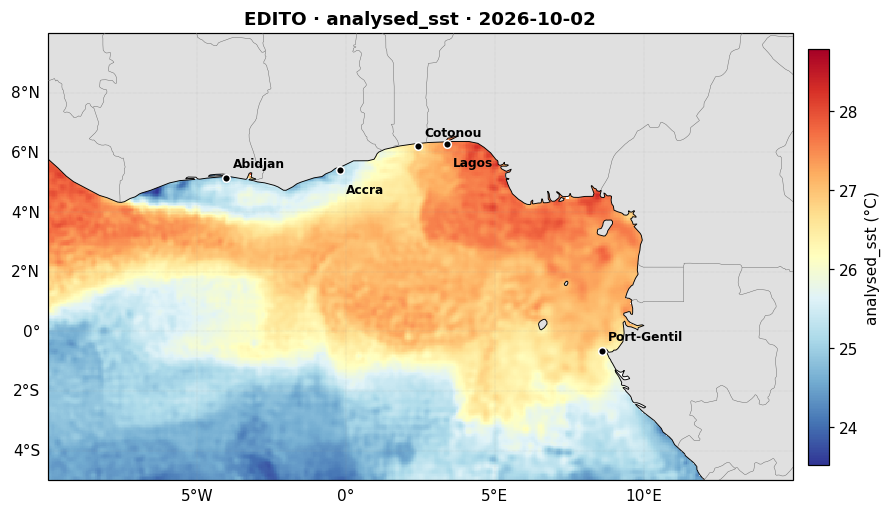

analysed_sst: min 23.53, max 28.79 °C over Gulf of Guinea


In [48]:
# 💻 Cell 4.3 — open a cloud-optimised (Zarr) asset directly and map the latest day over our region

def open_arco_zarr(href):
    """Open a public Copernicus Marine / EDITO Zarr store.
    Chunks that contain only land are not stored; the bucket answers '403' for them -> read them as empty (NaN)."""
    try:
        from zarr.storage import FsspecStore                     # zarr-python 3
        class _Store(FsspecStore):
            async def get(self, key, prototype, byte_range=None):
                try:
                    return await super().get(key, prototype, byte_range)
                except Exception as err:
                    if getattr(err, "status", None) == 403 or "403" in str(err):
                        return None                                # missing (land) chunk -> NaN
                    raise
        store = _Store.from_url(href, read_only=True)
        return xr.open_dataset(store, engine="zarr", zarr_format=2, consolidated=True)
    except ImportError:                                            # zarr-python 2
        import fsspec, aiohttp
        mapper = fsspec.get_mapper(href, missing_exceptions=(FileNotFoundError, KeyError, PermissionError,
                                                             aiohttp.ClientResponseError))
        return xr.open_dataset(mapper, engine="zarr", consolidated=True)

# keep only real Zarr stores (not the "data-explorer" web pages), prefer map-friendly (geoChunked) global products
cand = assets[assets["href"].str.rstrip("/").str.endswith(".zarr")
              & ~assets["href"].str.contains("data-explorer", case=False)].copy()
cand["geo"]   = cand["href"].str.contains("geoChunked", case=False)
cand["glo"]   = cand["href"].str.contains("_GLO_|GLO-", case=True)
cand["ostia"] = cand["href"].str.contains("METOFFICE-GLO-SST-L4", case=False)
cand = cand.sort_values(["ostia", "glo", "geo", "end"], ascending=False)

if cand.empty:
    print("No Zarr store here — try another COLLECTION in Cell 4.2.")
else:
    display(cand[["title", "end", "asset", "href"]].head(5))   # the best candidates, best first
    href = cand.iloc[0]["href"]
    print("Opening:", href)
    edito_ds = open_arco_zarr(href)                              # lazy: only the metadata is read
    display(edito_ds)

    # main variable and coordinate names used in this file
    var = list(edito_ds.data_vars)[0]
    lat = "latitude" if "latitude" in edito_ds.coords else "lat"
    lon = "longitude" if "longitude" in edito_ds.coords else "lon"
    da = edito_ds[var]

    # cut out our region (works whether latitude is stored south→north or north→south)
    lat_vals = edito_ds[lat].values
    lat_slice = (slice(REGION["minimum_latitude"], REGION["maximum_latitude"]) if lat_vals[0] < lat_vals[-1]
                 else slice(REGION["maximum_latitude"], REGION["minimum_latitude"]))
    da = da.sel({lat: lat_slice, lon: slice(REGION["minimum_longitude"], REGION["maximum_longitude"])})
    if da.sizes.get(lat, 0) == 0 or da.sizes.get(lon, 0) == 0:
        raise ValueError("This product does not cover the region — pick another href from the table above.")

    # latest day, top level if there is a depth axis
    if "time" in da.dims:
        da = da.isel(time=-1)
    for d in ("depth", "elevation"):
        if d in da.dims:
            da = da.isel({d: 0})
    da = da.load().rename({lat: "latitude", lon: "longitude"})

    # Kelvin → °C for temperatures
    units = da.attrs.get("units", "")
    if units.lower() in ("k", "kelvin") or float(da.mean()) > 200:
        da, units = da - 273.15, "°C"

    when = str(da["time"].values)[:10] if "time" in da.coords else ""
    fig, ax = map_axes(figsize=(8, 4.6))
    show_field(ax, da, cmap="RdYlBu_r", label=f"{var} ({units})")
    mark_points(ax)
    ax.set_title(f"EDITO · {var} · {when}")
    plt.show()
    print(f"{var}: min {float(da.min()):.2f}, max {float(da.max()):.2f} {units} over {REGION_NAME}")

INFO - 2026-10-04T02:24:26Z - Selected dataset version: "202311"
INFO - 2026-10-04T02:24:26Z - Selected dataset part: "latest"
WARNING - 2026-10-04T02:24:26Z - Some of your subset selection [2026-08-31 23:00:00+00:00, 2026-09-29 23:00:00+00:00] for the time dimension exceed the dataset coordinates [2026-09-03 00:00:00+00:00, 2026-10-03 22:25:00+00:00]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████| [00:01<00:00]

1,424 near-surface temperature measurements from 87 platforms


,measurements,platforms
platform_type,,
PF,1085,41
TS,281,45
MO,58,1


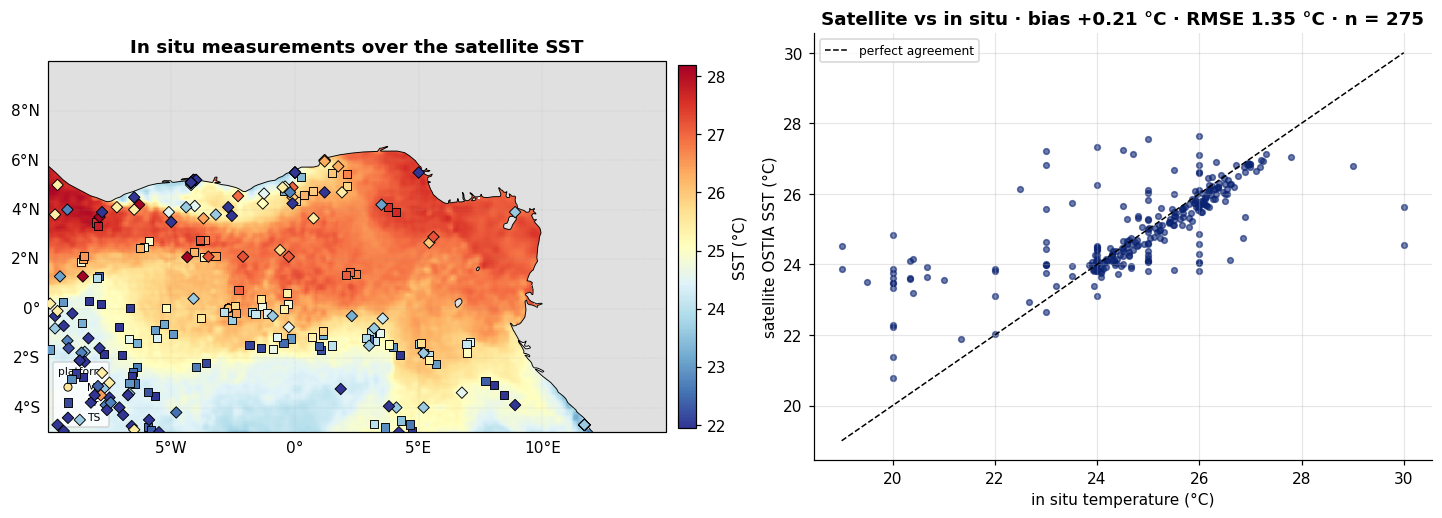

<div style="border-left:6px solid #1A54EB; background:#F4F7FC; padding:10px 14px; margin:8px 0; border-radius:4px"><b style="color:#1A54EB">Copernicus Marine and EDITO: which one when?</b><br><b>Copernicus Marine</b> is the authoritative source of the ocean products you used in Part 3, with documentation, quality information and the Toolbox. <b>EDITO</b> brings those products together with EMODnet and other data, models and cloud computing, so you can analyse and simulate in one place. Same ocean, two doors: a data service and a digital-twin platform.</div>

---
# Part 5 · Wrap-up, self-check and next steps <span style="color:#888; font-size:16px">(8 min)</span>

### What you did today
✅ Found the OPERA resources · ✅ climbed the MyOcean viewer ladder · ✅ decoded a dataset ID · ✅ opened satellite, model and wave data for your region in Python ·
✅ compared a model with observations · ✅ searched the EDITO catalogue.

### Self-check (answers in the drop-downs)

1. <details><summary>Why do we use <b>global</b> Copernicus Marine products for African coasts?</summary>There is no dedicated West African regional product; global products (1/12° for physics) cover Africa. Regional downscaling (e.g. SEA-FORWARD) adds detail.</details>
2. <details><summary>What does <code>anfc</code> mean in a dataset ID, and what is its counterpart for long time series?</summary><code>anfc</code> = analysis and forecast (near real time). <code>my</code> = multi-year (reanalysis), for climate studies.</details>
3. <details><summary>Why check a dry run before <code>subset()</code>?</summary>To see the size of the request before downloading, and avoid filling your disk or waiting for nothing.</details>
4. <details><summary>Name two reasons why model and satellite SST can differ near the coast.</summary>Different quantities (top model layer vs foundation SST), coarse resolution near complex coastlines, coastal processes and fewer good-quality observations close to land.</details>

### Your next steps with OPERA

| Next step | When | Link |
|---|---|---|
| Ocean Literacy materials: share them | now | [Resource Centre](https://www.unoceanprediction.org/en/resource-center?field_resource_type%5B0%5D=ocean_literacy_materials) |
| Advanced Interactive Activities, Set 1 | 21 Oct – 5 Nov 2026 | [apply.ggosss.org/aia-set1](https://apply.ggosss.org/aia-set1/) |
| MOOC 2 · Building an Ocean Forecasting System | from Nov 2026 | [OceanPrediction DCC](https://www.unoceanprediction.org/) |
| SEA-FORWARD documentation | now; workshop & hackathon after MOOC 2 | [sea-forward.readthedocs.io](https://sea-forward.readthedocs.io/en/latest/) |
| Keep learning Copernicus Marine | anytime | [Help Centre](https://help.marine.copernicus.eu/en/) · [Toolbox docs](https://toolbox-docs.marine.copernicus.eu/) |
| Keep exploring EDITO | anytime | [dive.edito.eu](https://dive.edito.eu/) · [Datalab](https://datalab.dive.edito.eu/) |

### References and data credits
- Alvarez-Fanjul, E., and Coauthors, 2022: *Implementing Operational Ocean Monitoring and Forecasting Systems* (ETOOFS Guide). IOC-UNESCO / Copernicus Marine Service.
- Ocean Forecasting Co-Design Team, 2024: *Ocean Forecasting Architecture Guide*. OceanPrediction DCC, Mercator Ocean International. doi:10.48670/oofsarchitecture
- Data: **E.U. Copernicus Marine Service Information** — OSTIA SST (SST_GLO_SST_L4_NRT_OBSERVATIONS_010_001), Global Ocean Physics Analysis and Forecast (GLOBAL_ANALYSISFORECAST_PHY_001_024), Global Ocean Waves Analysis and Forecast (GLOBAL_ANALYSISFORECAST_WAV_001_027), Global Ocean Biogeochemistry Analysis and Forecast (GLOBAL_ANALYSISFORECAST_BGC_001_028). Cite each product with the DOI on its product page.
- EDITO, European Digital Twin Ocean — [edito.eu](https://www.edito.eu/).

<div style="background:#0A2372; color:white; padding:14px 20px; border-radius:6px; margin-top:12px">
<b style="color:#FFCC03">OPERA Capacity Development Activities</b> · Funded by the European Union · OceanPrediction Decade Collaborative Centre ·
Mercator Ocean International · ICMPA-UNESCO Chair (Université d'Abomey-Calavi) · GGOSSS<br>
<span style="color:#009E8A">Thank you — please share your feedback with the trainers.</span>
</div>